In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from pathlib import Path

# === CONFIGURATION ===
class Config:
    DEBUG_MODE = False
    OUTPUT_DIR = 'working'
    BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")

config = Config()

# === DATASET ===
class MelSpectrogramDataset(Dataset):
    def __init__(self, data_dict, label_dict):
        self.samples = list(data_dict.keys())
        self.data_dict = data_dict
        self.label_dict = label_dict

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        samplename = self.samples[idx]
        mel = self.data_dict[samplename]
        label = self.label_dict[samplename]
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return mel_tensor, label_tensor

# === MODEL ===
class MelCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

# === DATA HANDLING ===
def load_data_structure(root_dir):
    loaded_data = {}
    sample_to_label = {}
    for class_dir in Path(root_dir).iterdir():
        if class_dir.is_dir():
            for file in class_dir.glob("*.npy"):
                samplename = file.stem
                species_id = samplename.split("-")[0]
                mel_spec = np.load(file)
                loaded_data[samplename] = mel_spec
                sample_to_label[samplename] = species_id
    return loaded_data, sample_to_label

def prepare_dataloaders(data_dict, label_dict, batch_size):
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(list(label_dict.values()))
    sample_names = list(label_dict.keys())
    sample_to_encoded = dict(zip(sample_names, encoded_labels))

    train_names, val_names = train_test_split(sample_names, test_size=0.2, random_state=42)
    train_data = {k: data_dict[k] for k in train_names}
    val_data = {k: data_dict[k] for k in val_names}
    train_labels = {k: sample_to_encoded[k] for k in train_names}
    val_labels = {k: sample_to_encoded[k] for k in val_names}

    train_ds = MelSpectrogramDataset(train_data, train_labels)
    val_ds = MelSpectrogramDataset(val_data, val_labels)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)

    return train_dl, val_dl, len(label_encoder.classes_)

# === EVALUATION ===
def evaluate_roc_auc(model, dataloader, device, num_classes):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    y_true = label_binarize(all_targets, classes=np.arange(num_classes))
    scored_classes = np.where(y_true.sum(axis=0) > 0)[0]

    if len(scored_classes) == 0:
        return 0.0

    try:
        return roc_auc_score(y_true[:, scored_classes], all_probs[:, scored_classes], average="macro")
    except ValueError:
        return 0.0

# === TRAINING ===
def train_model(train_dl, val_dl, num_classes, epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MelCNN(num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    auc_history = []
    best_auc = 0.0

    for epoch in range(epochs):
        model.train()
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()

        val_auc = evaluate_roc_auc(model, val_dl, device, num_classes)
        auc_history.append(val_auc)

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), config.BEST_MODEL_PATH)

        print(f"Epoch {epoch+1}/{epochs} — ROC AUC: {val_auc:.4f} {'<-- best' if val_auc == best_auc else ''}")

    print(f"Training complete. Best ROC AUC: {best_auc:.4f}")
    return model, auc_history

# === PLOTTING ===
def plot_auc_history(auc_history):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(auc_history) + 1), auc_history, marker='o')
    plt.title("Validation ROC AUC over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("ROC AUC")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [2]:
ROOT_DIR = Path(config.OUTPUT_DIR) / "mel_spectrograms"
print(f"Scanning: {ROOT_DIR}")
loaded_bird_data, sample_to_label = load_data_structure(ROOT_DIR)

Scanning: working/mel_spectrograms


In [3]:
all_classes = sorted(set(sample_to_label.values()))
print(f"Total classes found: {len(all_classes)}")
print(f"First 5 classes: {all_classes[:5]}")
print(f"Total samples: {len(loaded_bird_data)}")

train_dl, val_dl, num_classes = prepare_dataloaders(loaded_bird_data, sample_to_label, batch_size=32)
model, auc_history  = train_model(train_dl, val_dl, num_classes=num_classes, epochs=25, lr=1e-4)

Total classes found: 206
First 5 classes: ['1139490', '1192948', '1194042', '126247', '1346504']
Total samples: 28564
Epoch 1/25 — ROC AUC: 0.5655 <-- best
Epoch 2/25 — ROC AUC: 0.7003 <-- best
Epoch 3/25 — ROC AUC: 0.8727 <-- best
Epoch 4/25 — ROC AUC: 0.9069 <-- best
Epoch 5/25 — ROC AUC: 0.9265 <-- best
Epoch 6/25 — ROC AUC: 0.9348 <-- best
Epoch 7/25 — ROC AUC: 0.9436 <-- best
Epoch 8/25 — ROC AUC: 0.9473 <-- best
Epoch 9/25 — ROC AUC: 0.9489 <-- best
Epoch 10/25 — ROC AUC: 0.9522 <-- best
Epoch 11/25 — ROC AUC: 0.9530 <-- best
Epoch 12/25 — ROC AUC: 0.9541 <-- best
Epoch 13/25 — ROC AUC: 0.9573 <-- best
Epoch 14/25 — ROC AUC: 0.9572 
Epoch 15/25 — ROC AUC: 0.9568 
Epoch 16/25 — ROC AUC: 0.9571 
Epoch 17/25 — ROC AUC: 0.9574 <-- best
Epoch 18/25 — ROC AUC: 0.9568 
Epoch 19/25 — ROC AUC: 0.9526 
Epoch 20/25 — ROC AUC: 0.9547 
Epoch 21/25 — ROC AUC: 0.9532 
Epoch 22/25 — ROC AUC: 0.9517 
Epoch 23/25 — ROC AUC: 0.9537 
Epoch 24/25 — ROC AUC: 0.9539 
Epoch 25/25 — ROC AUC: 0.9517 
Trai

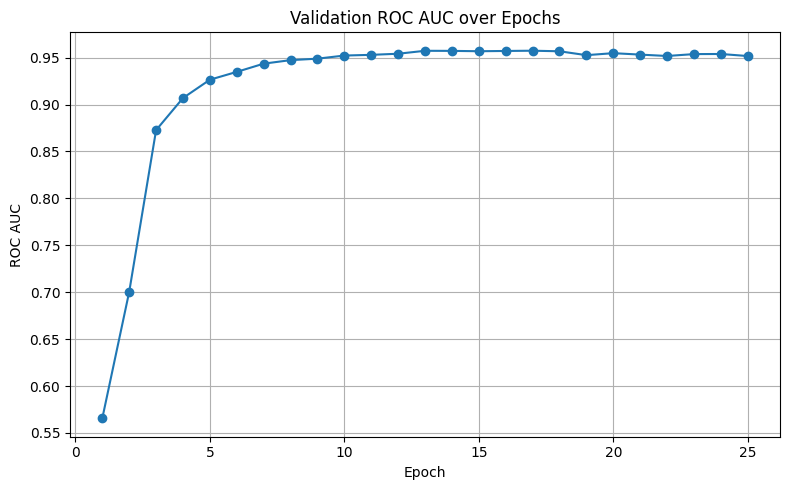

MelCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=Tr

In [4]:
# Plot AUC over time
plot_auc_history(auc_history)

# Load the best model later

best_model = MelCNN(num_classes=num_classes)
best_model.load_state_dict(torch.load(config.BEST_MODEL_PATH))
best_model.eval()


In [5]:
# Grab one batch from validation loader
sample_batch = next(iter(val_dl))
mel_batch, label_batch = sample_batch

# Send to same device as model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mel_batch = mel_batch.to(device)

# Predict
preds = model.predict(mel_batch)

# Print predictions and true labels for first 5
print("Predicted:", preds[:5].cpu().numpy())
print("Actual:   ", label_batch[:5].numpy())


Predicted: [203 189  12  87 117]
Actual:    [203 189  12  87 176]
